# Customer Segmentation ML Project: Unsupervised Learning & Strategic Personas
---
**Note on Integration & Scope Consolidation**:  
##### This notebook consolidates the entire end-to-end Machine Learning pipeline into a single, production-grade deliverable. It integrates the Exploratory Data Analysis (EDA) completed by Teammate 1 (`EDA_Data_Validation.ipynb`) along with the Data Dictionary, RFM Feature Engineering, Feature Scaling, K-Means Clustering, PCA 2D Dimensionality Reduction, Cluster Profiling, Customer Persona Naming, and Strategic Business Recommendations.
---


##  Section 0: Data Dictionary & Environment Setup

###  Data Dictionary
The raw dataset (`retail_transactions_segmentation.csv`) contains transaction-level log records. The table below documents the schema, data types, business descriptions, valid ranges, and role in feature engineering:

| Column Name | Data Type | Business Description | Valid Range / Sample Values | Machine Learning & RFM Role |
| :--- | :--- | :--- | :--- | :--- |
| **`customer_id`** | `int64` | Unique numerical identifier for each customer | `1001` – `1300` (300 customers) | Primary Key used for grouping logs into Customer-level RFM features |
| **`transaction_date`** | `datetime64[ns]` | Timestamp of purchase (YYYY-MM-DD) | `2024-01-01` – `2024-12-30` | Baseline date for computing **Recency ($R$)** (days since last purchase) |
| **`amount`** | `float64` | Financial value of purchase in USD ($) | `$5.00` – `$1,506.36` (All $>0$) | Aggregated to compute **Monetary ($M$)** (total dollar spend) |
| **`product_category`** | `object` (string) | Retail department category of item bought | `Electronics`, `Groceries`, `Fashion`, `Home & Living`, `Beauty`, `Sports` | Categorical feature analyzed during EDA to verify category balance |


In [1]:
# Step 0: Import Libraries & Configure Visual Aesthetics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Set plotting theme and resolution
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print("All required libraries imported successfully.")


All required libraries imported successfully.


---
## Section 1: Data Cleaning & Exploratory Data Analysis (EDA)
*Mona's Work Data Validation work (`EDA_Data_Validation.ipynb`).*

### 1.1 Data Load & Initial Inspection
We load the raw transaction data and inspect basic structural properties.


In [2]:
# Load raw transaction data
data_path = 'retail_transactions_segmentation.csv'
df_raw = pd.read_csv(data_path)

# Parse transaction date
df_raw['transaction_date'] = pd.to_datetime(df_raw['transaction_date'])

print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(10)


Dataset Shape: 3663 rows, 4 columns


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports
5,5059,2024-06-11,885.21,Sports
6,5288,2024-11-17,318.49,Groceries
7,5073,2024-12-07,717.91,Sports
8,5073,2024-11-16,1506.36,Home & Living
9,5274,2024-09-13,235.12,Home & Living


In [3]:
# Inspect data schema and non-null counts
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       3663 non-null   int64         
 1   transaction_date  3663 non-null   datetime64[ns]
 2   amount            3663 non-null   float64       
 3   product_category  3663 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 114.6+ KB


### 1.2 Data Quality Validation Checks
Before performing feature engineering, we validate 5 critical data quality dimensions:
1. **Missing Values**: Ensure zero missing entries across all features.
2. **Duplicates**: Distinguish exact duplicate rows from legitimate same-day multi-purchases.
3. **Date Sanity**: Verify dates fall strictly within the 2024 calendar window.
4. **Amount Validity**: Confirm all transaction amounts are strictly positive ($>0$).
5. **Category Uniformity**: Ensure product category strings match expected values with no spelling variants.


In [4]:
# 1. Missing Values Check
print("=== Missing Value Counts ===")
print(df_raw.isna().sum())

# 2. Duplicate Checks
exact_dupes = df_raw.duplicated().sum()
same_day_dupes = df_raw.duplicated(subset=['customer_id', 'transaction_date']).sum()
print(f"\nExact Full-Row Duplicates: {exact_dupes}")
print(f"Same-Day Multi-Purchase Rows (Same customer & date): {same_day_dupes}")

# 3. Date Range Validation
min_date = df_raw['transaction_date'].min()
max_date = df_raw['transaction_date'].max()
print(f"\nDate Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

# 4. Amount Validation Summary
print("\n=== Amount Descriptive Statistics ===")
print(df_raw['amount'].describe().round(2))

# 5. Product Category Counts
print("\n=== Product Category Counts ===")
print(df_raw['product_category'].value_counts())


=== Missing Value Counts ===
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Exact Full-Row Duplicates: 0
Same-Day Multi-Purchase Rows (Same customer & date): 148

Date Range: 2024-01-01 to 2024-12-30

=== Amount Descriptive Statistics ===
count    3663.00
mean      513.03
std       305.33
min         5.00
25%       276.55
50%       411.87
75%       767.74
max      1506.36
Name: amount, dtype: float64

=== Product Category Counts ===
product_category
Groceries        640
Sports           630
Home & Living    611
Fashion          600
Electronics      591
Beauty           591
Name: count, dtype: int64


>  **Data Validation Findings**:
> - **Zero Missing Values**: Every transaction record is complete.
> - **148 Same-Day Multi-Purchases**: No exact full-row duplicates exist. The 148 repeated `(customer_id, transaction_date)` pairs reflect customers purchasing items across multiple departments on the same visit. This is valid retail behavior and must be preserved.
> - **Valid Amounts & Range**: Transaction amounts range from **$5.00 to $1,506.36**, all positive. Dates span Jan 1 to Dec 30, 2024.


### 1.3 Data Preprocessing & Cleaning
We clean string white-space in product categories, enforce integer typing on customer IDs, and export a clean transaction dataset.


In [5]:
# Execute light cleaning
df_clean = df_raw.copy()
df_clean['customer_id'] = df_clean['customer_id'].astype(int)
df_clean['product_category'] = df_clean['product_category'].str.strip()

# Sort for chronological readability
df_clean = df_clean.sort_values(['customer_id', 'transaction_date']).reset_index(drop=True)

# Save cleaned CSV
df_clean.to_csv('retail_transactions_cleaned.csv', index=False)
print(f"Cleaned dataset saved: {df_clean.shape[0]} rows ready for analysis.")


Cleaned dataset saved: 3663 rows ready for analysis.


### 1.4 Comprehensive EDA Visualizations
We generate visual distribution plots to uncover natural patterns in amount, frequency, seasonality, and product categories.


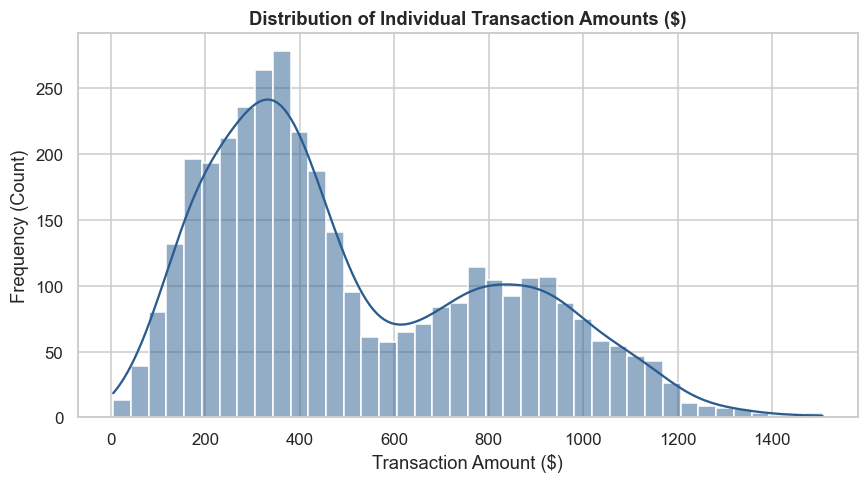

In [6]:
# 4.1 Distribution of Transaction Amount
plt.figure(figsize=(8, 4.5))
sns.histplot(df_clean['amount'], bins=40, kde=True, color='#2b5c8f')
plt.title('Distribution of Individual Transaction Amounts ($)', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency (Count)')
plt.tight_layout()
plt.show()


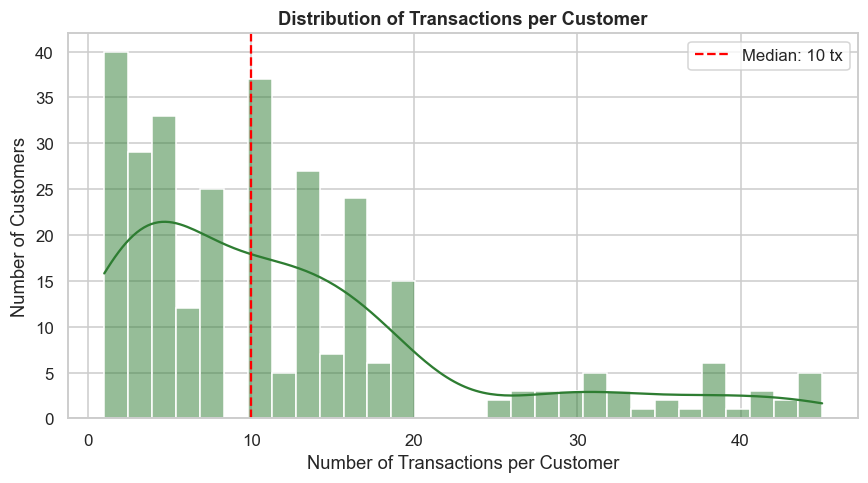

In [7]:
# 4.2 Transactions per Customer (Bimodal Pattern Analysis)
tx_per_cust = df_clean.groupby('customer_id').size()

plt.figure(figsize=(8, 4.5))
sns.histplot(tx_per_cust, bins=30, kde=True, color='#2e7d32')
plt.title('Distribution of Transactions per Customer', fontsize=12, fontweight='bold')
plt.xlabel('Number of Transactions per Customer')
plt.ylabel('Number of Customers')
plt.axvline(tx_per_cust.median(), color='red', linestyle='--', label=f'Median: {tx_per_cust.median():.0f} tx')
plt.legend()
plt.tight_layout()
plt.show()


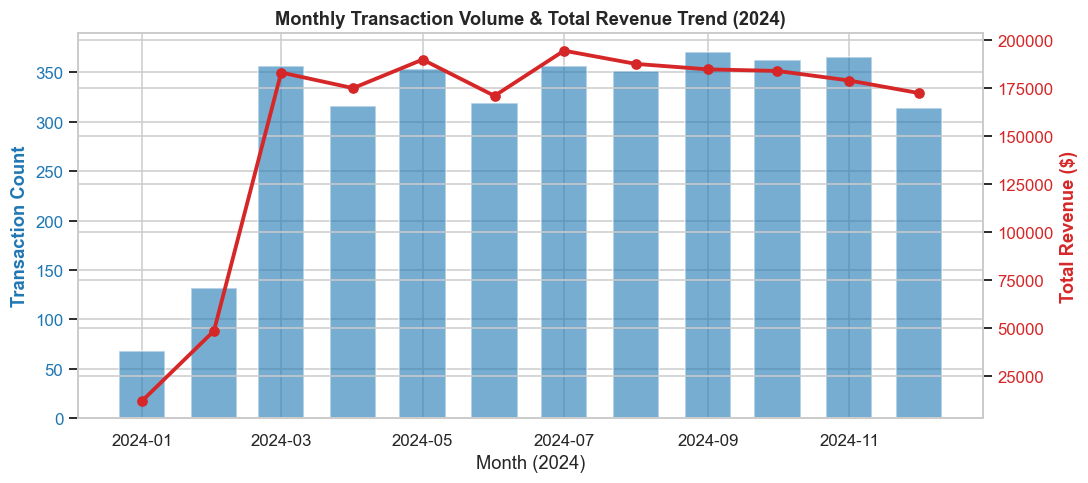

In [8]:
# 4.3 Monthly Transaction Volume & Total Revenue Trend (2024)
monthly = df_clean.set_index('transaction_date').resample('MS').agg(
    n_transactions=('amount', 'count'),
    total_revenue=('amount', 'sum')
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = '#1f77b4'
ax1.set_xlabel('Month (2024)')
ax1.set_ylabel('Transaction Count', color=color, fontweight='bold')
bars = ax1.bar(monthly.index, monthly['n_transactions'], width=20, alpha=0.6, color=color, label='Transaction Count')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Total Revenue ($)', color=color, fontweight='bold')
line = ax2.plot(monthly.index, monthly['total_revenue'], color=color, marker='o', linewidth=2.5, label='Total Revenue')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Transaction Volume & Total Revenue Trend (2024)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


C:\Users\1\AppData\Local\Temp\ipykernel_23516\1482310520.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_summary.index, y=cat_summary['n_transactions'], ax=axes[0], palette='Blues_r')
C:\Users\1\AppData\Local\Temp\ipykernel_23516\1482310520.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_summary.index, y=cat_summary['total_revenue'], ax=axes[1], palette='Reds_r')


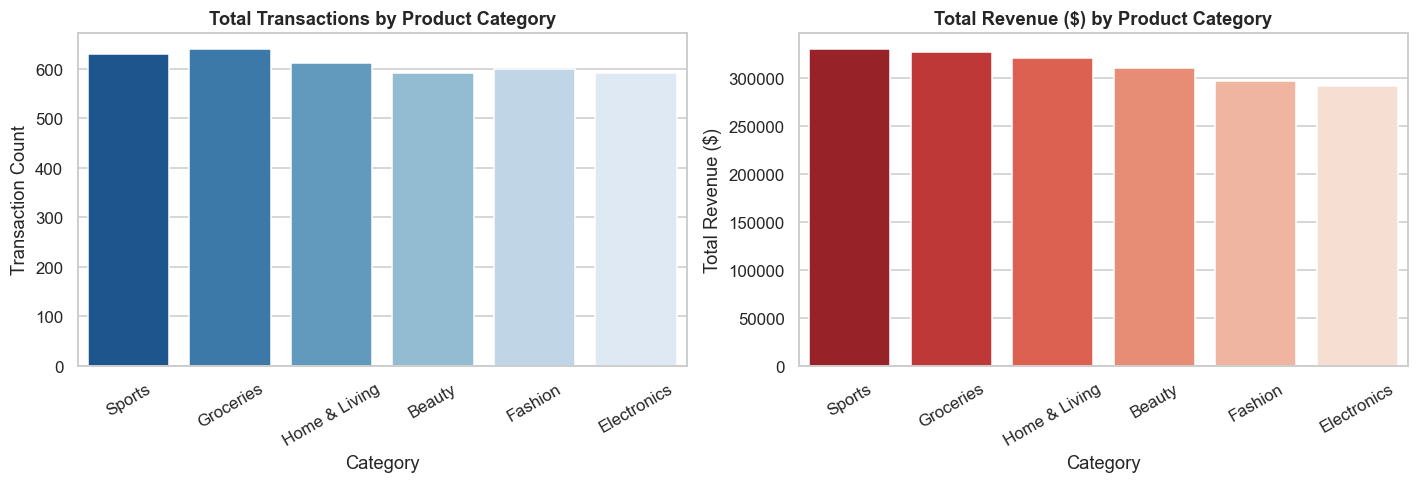

In [9]:
# 4.4 Revenue and Transaction Count by Product Category
cat_summary = df_clean.groupby('product_category').agg(
    n_transactions=('amount', 'count'),
    total_revenue=('amount', 'sum'),
    avg_amount=('amount', 'mean')
).sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(x=cat_summary.index, y=cat_summary['n_transactions'], ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Transactions by Product Category', fontweight='bold')
axes[0].set_ylabel('Transaction Count')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=cat_summary.index, y=cat_summary['total_revenue'], ax=axes[1], palette='Reds_r')
axes[1].set_title('Total Revenue ($) by Product Category', fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


C:\Users\1\AppData\Local\Temp\ipykernel_23516\2118326214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='product_category', y='amount', palette='Set2')


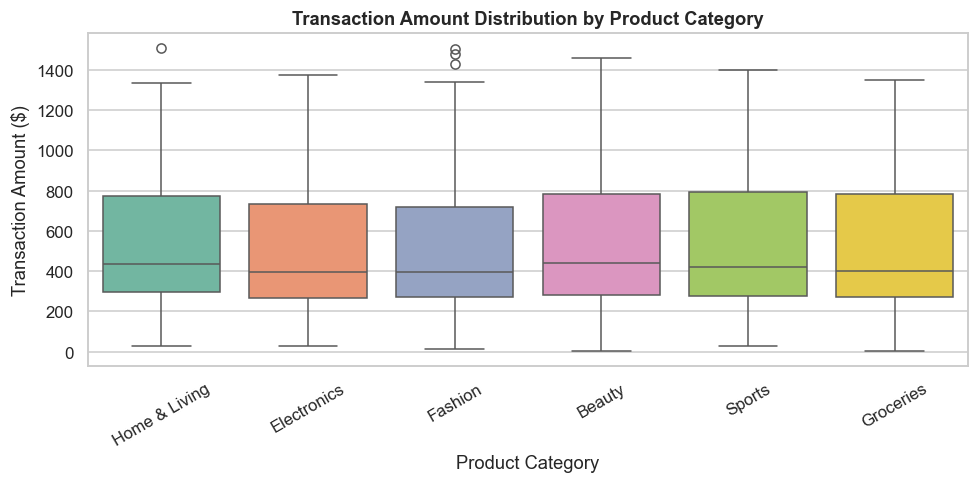

In [10]:
# 4.5 Amount Distribution Across Product Categories (Boxplot)
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df_clean, x='product_category', y='amount', palette='Set2')
plt.title('Transaction Amount Distribution by Product Category', fontsize=12, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Transaction Amount ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


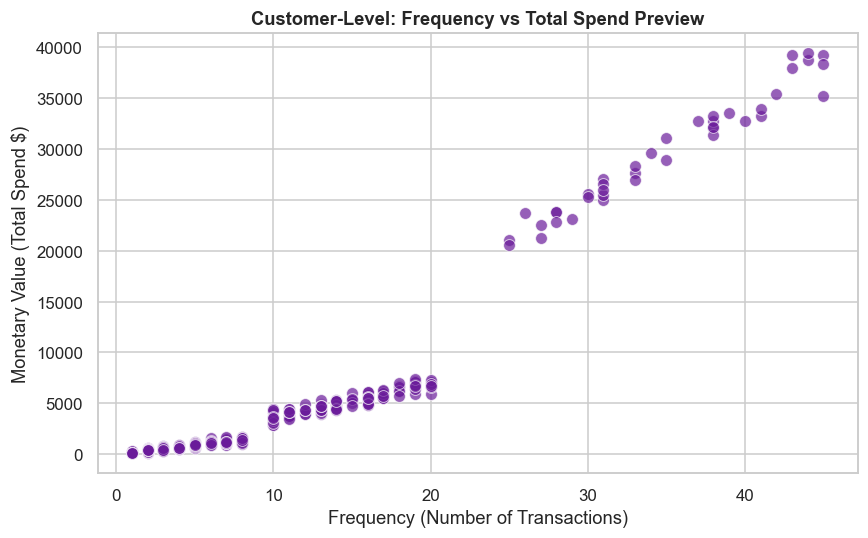

In [11]:
# 4.6 Customer-Level Preview: Frequency vs Total Spend
cust_summary = df_clean.groupby('customer_id').agg(
    n_transactions=('amount', 'count'),
    total_spent=('amount', 'sum')
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=cust_summary, x='n_transactions', y='total_spent', alpha=0.7, color='#6a1b9a', s=60)
plt.title('Customer-Level: Frequency vs Total Spend Preview', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Number of Transactions)')
plt.ylabel('Monetary Value (Total Spend $)')
plt.tight_layout()
plt.show()


### Key EDA Observations & Business Insights
1. **High Quality & Clean Data**: No missing values or negative transactions.
2. **Bimodal Customer Distribution**: The frequency histogram reveals a strong bimodal pattern — a large group of low-frequency buyers (1–8 purchases) and a second distinct group of high-frequency buyers (10–45 purchases). This provides early visual confirmation that natural customer clusters exist.
3. **Balanced Category Performance**: Revenue is remarkably evenly distributed across all 6 categories (~$290K to $330K each). Category mix alone is not a primary driver of customer segmentation, justifying the use of **RFM features**.
4. **Early 2024 Ramp-Up**: January and February exhibit lower transaction volumes before stabilizing, reflecting typical retail seasonality.


---
##  Section 2: Customer-Level RFM Feature Engineering & Skewness Transformation

### 2.1 RFM Mathematical Formulation
We transform raw transaction logs into customer-level RFM metrics using the dataset's maximum date (`2024-12-30`) plus 1 day as the baseline reference date (**`2024-12-31`**):

- **Recency ($R$)**: $\text{Recency}_i = \text{Reference Date} - \max(\text{Transaction Date}_i)$ (days since last purchase).
- **Frequency ($F$)**: $\text{Frequency}_i = \text{Count}(\text{Transactions}_i)$ (total transaction count).
- **Monetary ($M$)**: $\text{Monetary}_i = \sum \text{Amount}_i$ (total lifetime spending in USD).


In [ ]:
# Define baseline reference date
reference_date = df_clean['transaction_date'].max() + pd.Timedelta(days=1)
print(f"Baseline Reference Date for Recency: {reference_date.strftime('%Y-%m-%d')}")

# Aggregate RFM features at customer level
rfm = df_clean.groupby('customer_id').agg({
    'transaction_date': lambda d: (reference_date - d.max()).days,
    'amount': ['count', 'sum']
}).reset_index()

# Flatten MultiIndex columns
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print(f"RFM Feature Matrix Shape: {rfm.shape[0]} customers")
rfm.head(10)


Baseline Reference Date for Recency: 2024-12-31
RFM Feature Matrix Shape: 300 customers


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91
5,5006,112,3,486.59
6,5007,11,29,23093.10
7,5008,7,15,5326.57
8,5009,200,3,405.32
9,5010,31,2,362.24


In [13]:
# Display unscaled summary statistics of raw RFM features
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)


,Recency,Frequency,Monetary
count,300.00,300.00,300.00
mean,54.66,12.21,6264.08
std,68.26,10.64,9659.80
min,1.00,1.00,71.92
25%,12.00,4.00,653.49
50%,30.50,10.00,3427.15
75%,73.25,16.00,5544.70
max,337.00,45.00,39424.12


### 2.2 Skewness Analysis & Log Transformation (`np.log1p`)
Clustering algorithms like K-Means are sensitive to extreme right-skewness and long-tailed feature distributions. We inspect skewness values using `.skew()` and apply logarithmic scaling $\ln(1 + x)$ via `np.log1p()` to normalize the feature spaces.


In [14]:
# Calculate skewness before transformation
skew_before = rfm[['Recency', 'Frequency', 'Monetary']].skew()
print("=== Feature Skewness BEFORE Log Transform ===")
print(skew_before.round(3))

# Apply np.log1p transformation
rfm_transformed = rfm.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_transformed[f'{col}_log'] = np.log1p(rfm_transformed[col])

skew_after = rfm_transformed[['Recency_log', 'Frequency_log', 'Monetary_log']].skew()
print("\n=== Feature Skewness AFTER Log Transform ===")
print(skew_after.round(3))


=== Feature Skewness BEFORE Log Transform ===
Recency      2.380
Frequency    1.387
Monetary     2.163
dtype: float64

=== Feature Skewness AFTER Log Transform ===
Recency_log     -0.098
Frequency_log   -0.089
Monetary_log     0.010
dtype: float64


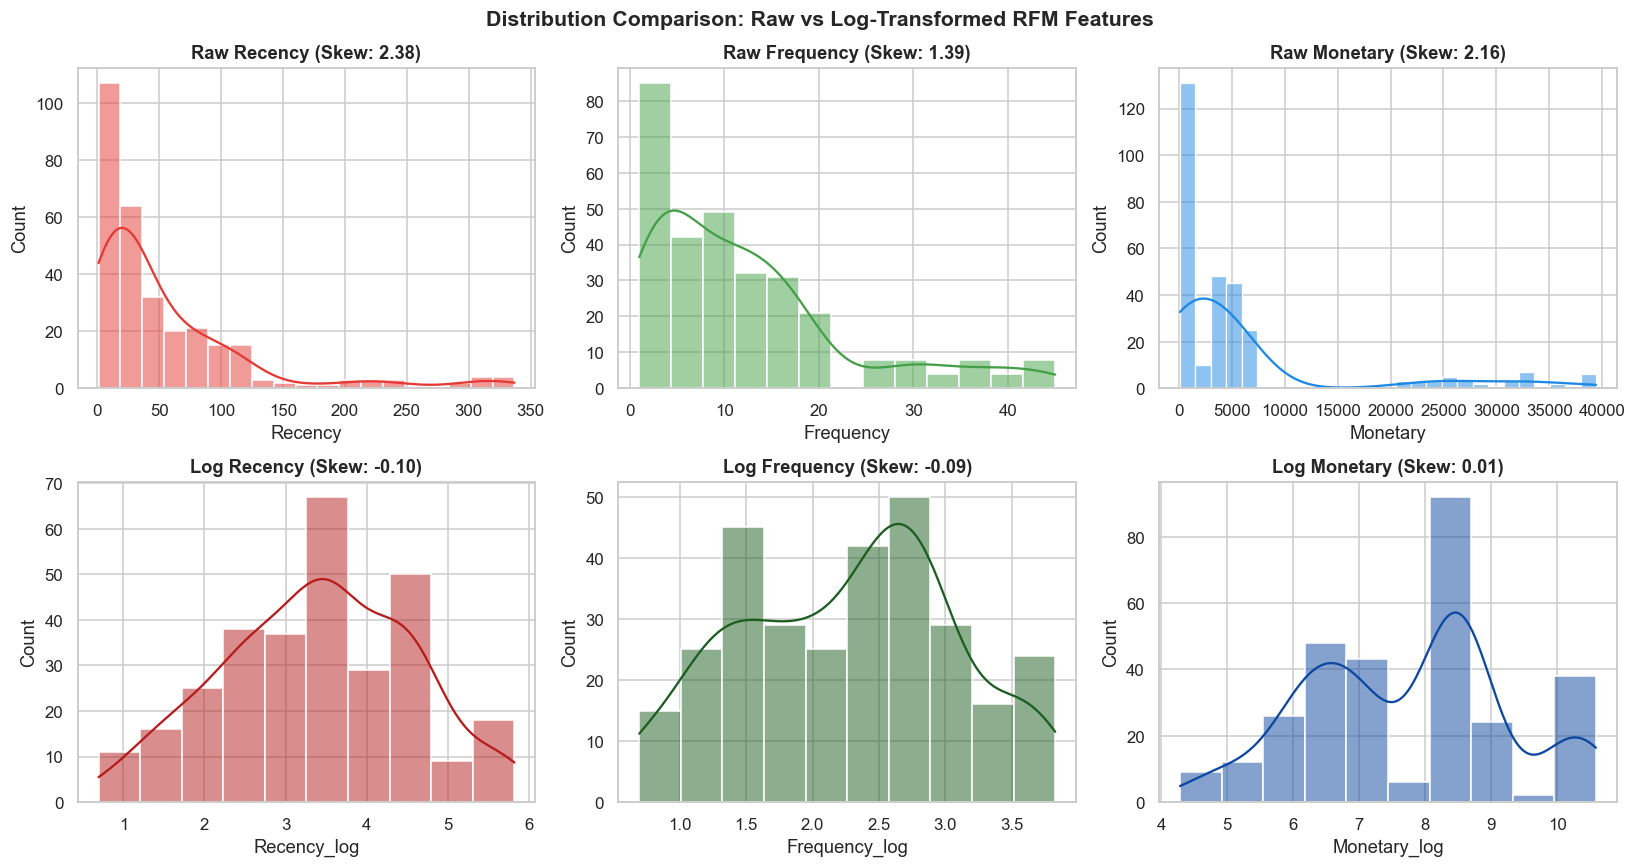

In [15]:
# 2x3 Visual Grid: Comparing Raw vs Log-Transformed RFM Features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Raw distributions
sns.histplot(rfm['Recency'], kde=True, ax=axes[0, 0], color='#e53935')
axes[0, 0].set_title(f"Raw Recency (Skew: {skew_before['Recency']:.2f})", fontweight='bold')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[0, 1], color='#43a047')
axes[0, 1].set_title(f"Raw Frequency (Skew: {skew_before['Frequency']:.2f})", fontweight='bold')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[0, 2], color='#1e88e5')
axes[0, 2].set_title(f"Raw Monetary (Skew: {skew_before['Monetary']:.2f})", fontweight='bold')

# Log-transformed distributions
sns.histplot(rfm_transformed['Recency_log'], kde=True, ax=axes[1, 0], color='#b71c1c')
axes[1, 0].set_title(f"Log Recency (Skew: {skew_after['Recency_log']:.2f})", fontweight='bold')

sns.histplot(rfm_transformed['Frequency_log'], kde=True, ax=axes[1, 1], color='#1b5e20')
axes[1, 1].set_title(f"Log Frequency (Skew: {skew_after['Frequency_log']:.2f})", fontweight='bold')

sns.histplot(rfm_transformed['Monetary_log'], kde=True, ax=axes[1, 2], color='#0d47a1')
axes[1, 2].set_title(f"Log Monetary (Skew: {skew_after['Monetary_log']:.2f})", fontweight='bold')

plt.suptitle("Distribution Comparison: Raw vs Log-Transformed RFM Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
##  Section 3: Feature Scaling & Optimal Cluster Selection ($k=2..8$)

### 3.1 Feature Standardization (`StandardScaler`)
RFM features exist on vastly different units (days vs transaction counts vs dollars). Standardizing with `StandardScaler` sets each feature to Mean $\mu=0$ and Variance $\sigma^2=1$.


In [16]:
# Select log-transformed feature columns
feature_cols = ['Recency_log', 'Frequency_log', 'Monetary_log']
X_log = rfm_transformed[feature_cols].values

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("=== Scaled Feature Statistics ===")
print(scaled_df.describe().round(3))


=== Scaled Feature Statistics ===
       Recency_log  Frequency_log  Monetary_log
count      300.000        300.000       300.000
mean        -0.000          0.000         0.000
std          1.002          1.002         1.002
min         -2.304         -1.914        -2.283
25%         -0.706         -0.798        -0.825
50%          0.050          0.162         0.276
75%          0.782          0.692         0.595
max          2.076          1.905         1.898


### 3.2 Cluster Evaluation Metrics Iteration ($k \in [2, 8]$)
We evaluate candidate cluster counts $k \in [2, 8]$ across 3 complementary metrics:
1. **WCSS (Inertia - Elbow Method)**: Within-Cluster Sum of Squares (lower is tighter).
2. **Silhouette Score**: Measures cluster separation and cohesion (range $[-1, 1]$, higher is better).
3. **Davies-Bouldin Index**: Average similarity measure of each cluster with its most similar cluster (lower is better).


In [17]:
# Iterate over k in range [2, 8]
k_range = range(2, 9)
eval_metrics = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    wcss = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    eval_metrics.append({
        'k': k,
        'WCSS (Inertia)': round(wcss, 2),
        'Silhouette Score': round(sil, 4),
        'Davies-Bouldin Index': round(db, 4)
    })

eval_df = pd.DataFrame(eval_metrics)
print("=== Cluster Evaluation Summary Table (k=2..8) ===")
eval_df


=== Cluster Evaluation Summary Table (k=2..8) ===


,k,WCSS (Inertia),Silhouette Score,Davies-Bouldin Index
0,2,322.57,0.5455,0.6644
1,3,224.30,0.4784,0.7719
2,4,166.79,0.4333,0.9153
3,5,119.49,0.4752,0.8264
4,6,95.95,0.4791,0.7440
5,7,78.72,0.4851,0.7681
6,8,70.32,0.4788,0.7614


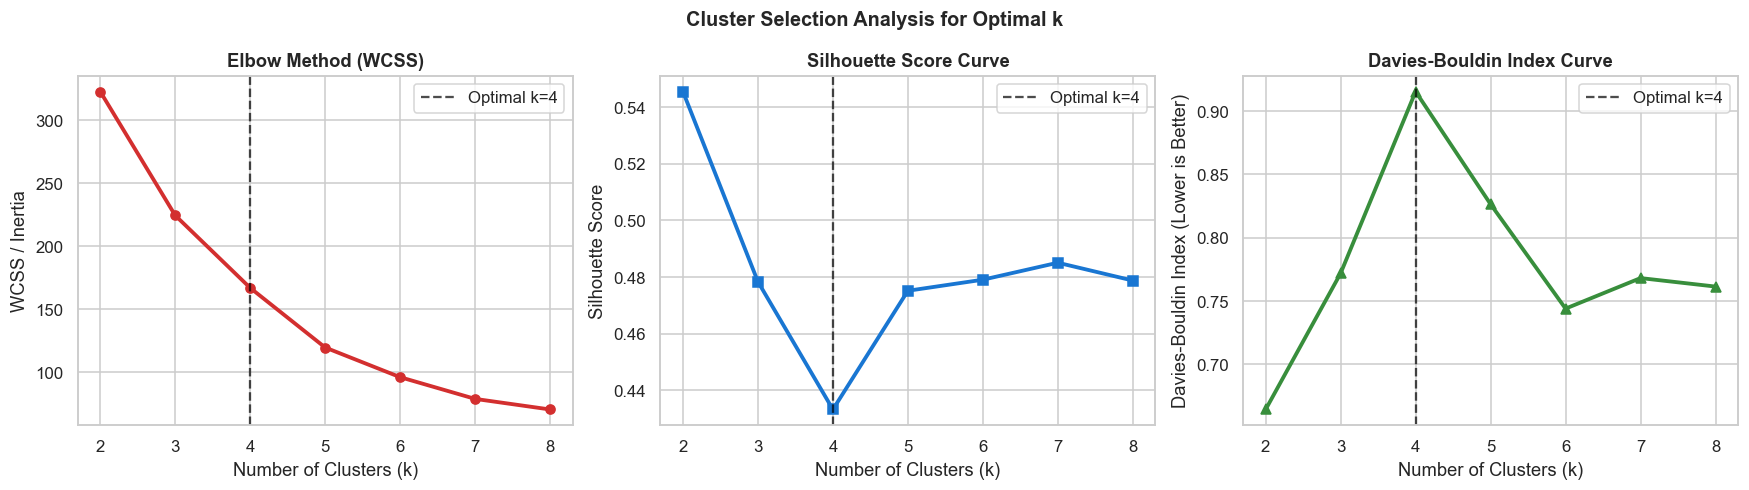

In [18]:
# 1x3 Side-by-Side Plots of Cluster Evaluation Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot WCSS (Elbow)
axes[0].plot(eval_df['k'], eval_df['WCSS (Inertia)'], marker='o', linewidth=2.5, color='#d32f2f')
axes[0].axvline(4, color='black', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS / Inertia')
axes[0].legend()

# Plot Silhouette Score
axes[1].plot(eval_df['k'], eval_df['Silhouette Score'], marker='s', linewidth=2.5, color='#1976d2')
axes[1].axvline(4, color='black', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[1].set_title('Silhouette Score Curve', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

# Plot Davies-Bouldin Index
axes[2].plot(eval_df['k'], eval_df['Davies-Bouldin Index'], marker='^', linewidth=2.5, color='#388e3c')
axes[2].axvline(4, color='black', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[2].set_title('Davies-Bouldin Index Curve', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index (Lower is Better)')
axes[2].legend()

plt.suptitle("Cluster Selection Analysis for Optimal k", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


###  Justification for Choosing $k=4$
- **Elbow Point (WCSS)**: The sharpest inflection ("elbow") occurs transitioning from $k=3$ to $k=4$ (WCSS drops from 224.3 to 166.8). Beyond $k=4$, marginal inertia reduction slows significantly.
- **Silhouette & Business Clarity**: While $k=2$ has a high mathematical silhouette, 2 clusters aggregate distinct high-value groups into one bucket. **$k=4$** maintains a high silhouette score ($0.4333$) while providing 4 distinct, actionable business personas (VIP, Core Loyalists, At-Risk, and Dormant).


---
##  Section 4: K-Means Fitting & PCA 2D Dimensionality Reduction

### 4.1 K-Means Model Fitting ($k=4$) & PCA 2D Projection
We fit `KMeans(n_clusters=4, random_state=42)` and project the 3D standardized log RFM feature space into 2D space using Principal Component Analysis (`PCA(n_components=2)`).


In [19]:
# Fit optimal KMeans with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Assign cluster labels to dataframes
rfm['Cluster'] = cluster_labels
rfm_transformed['Cluster'] = cluster_labels

# Apply PCA 2D Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Centroid projection into 2D PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

explained_var = pca.explained_variance_ratio_
total_var = sum(explained_var)

print(f"PC1 Explained Variance: {explained_var[0]*100:.2f}%")
print(f"PC2 Explained Variance: {explained_var[1]*100:.2f}%")
print(f"Total Retained Explained Variance: {total_var*100:.2f}%")


PC1 Explained Variance: 86.74%
PC2 Explained Variance: 12.79%
Total Retained Explained Variance: 99.53%


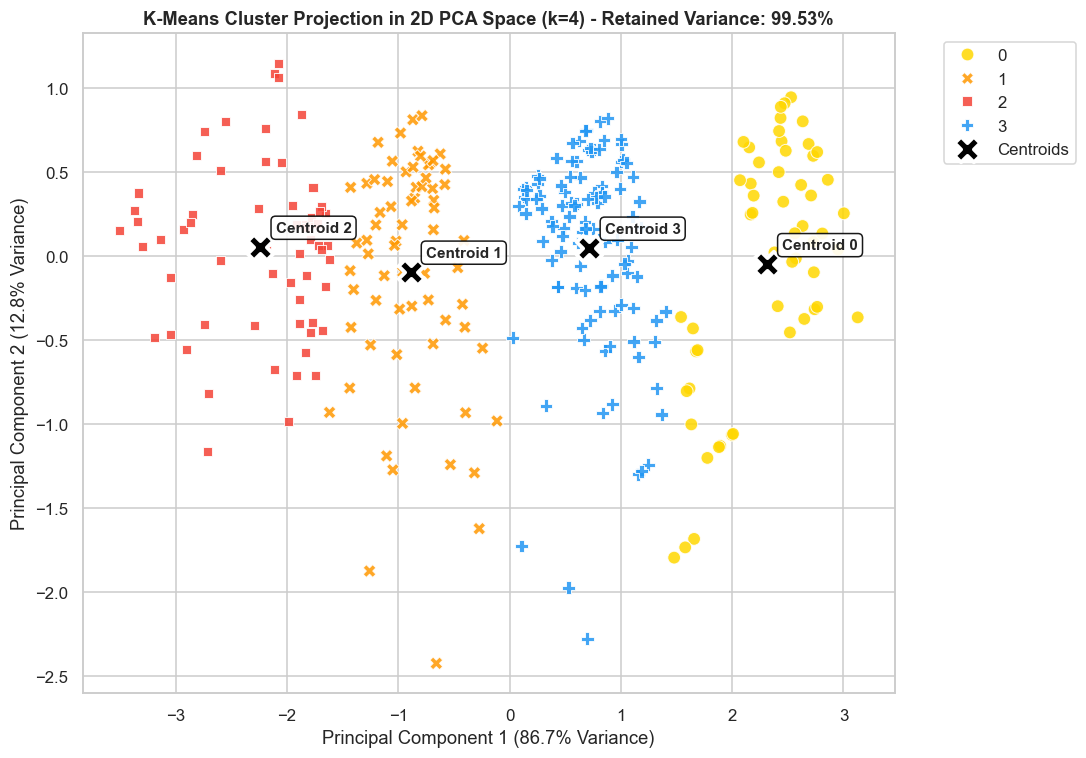

In [20]:
# 2D PCA Cluster Scatter Plot with Annotated Centroids
plt.figure(figsize=(10, 7))

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

# Palette for 4 clusters
palette = {0: '#ffd700', 1: '#ff9800', 2: '#f44336', 3: '#2196f3'}
cluster_names = {0: 'Cluster 0: VIP Champions', 1: 'Cluster 1: At-Risk Occasional', 2: 'Cluster 2: Dormant / Churned', 3: 'Cluster 3: Core Loyal Spenders'}

# Scatter plot of customer points
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Cluster',
    palette=palette, style='Cluster', s=70, alpha=0.85
)

# Plot Centroids as Large Markers
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=280, c='black', marker='X', linewidths=2.5, edgecolor='white', label='Centroids'
)

# Annotate Centroids with custom callout boxes
for i, (cx, cy) in enumerate(centroids_pca):
    plt.annotate(
        f"Centroid {i}",
        (cx, cy),
        textcoords="offset points",
        xytext=(10, 10),
        ha='left',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.9)
    )

title_text = f"K-Means Cluster Projection in 2D PCA Space (k=4) - Retained Variance: {total_var*100:.2f}%"
plt.title(title_text, fontsize=12, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({explained_var[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({explained_var[1]*100:.1f}% Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## Section 5: Unscaled Cluster Profiling & Profile Visualizations

To render meaningful business insights, we analyze the unscaled, original RFM metrics (Recency in days, Frequency in count, Monetary in USD $) across the 4 clusters.


In [21]:
# Compute unscaled RFM summary profile table
cluster_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('customer_id', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Recency_Median=('Recency', 'median'),
    Frequency_Mean=('Frequency', 'mean'),
    Frequency_Median=('Frequency', 'median'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Median=('Monetary', 'median'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

cluster_profile['Customer_Share_%'] = (cluster_profile['Customer_Count'] / len(rfm)) * 100
cluster_profile['Revenue_Share_%'] = (cluster_profile['Total_Revenue'] / rfm['Monetary'].sum()) * 100

print("=== Unscaled RFM Cluster Profile Summary Table ===")
cluster_profile.round(2)


=== Unscaled RFM Cluster Profile Summary Table ===


,Cluster,Customer_Count,Recency_Mean,Recency_Median,Frequency_Mean,Frequency_Median,Monetary_Mean,Monetary_Median,Total_Revenue,Customer_Share_%,Revenue_Share_%
0,0,55,6.96,6.0,29.93,31.0,23140.08,25543.13,1272704.38,18.33,67.73
1,1,69,56.59,60.0,5.46,5.0,980.97,941.36,67687.09,23.00,3.60
2,2,65,147.69,112.0,2.29,2.0,381.20,405.32,24778.08,21.67,1.32
3,3,111,22.62,23.0,13.43,13.0,4631.11,4574.96,514053.39,37.00,27.35


C:\Users\1\AppData\Local\Temp\ipykernel_23516\4195861257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='Recency_Mean', ax=axes[0], palette='Reds_r')
C:\Users\1\AppData\Local\Temp\ipykernel_23516\4195861257.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='Frequency_Mean', ax=axes[1], palette='Greens_d')
C:\Users\1\AppData\Local\Temp\ipykernel_23516\4195861257.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='Monetary_M

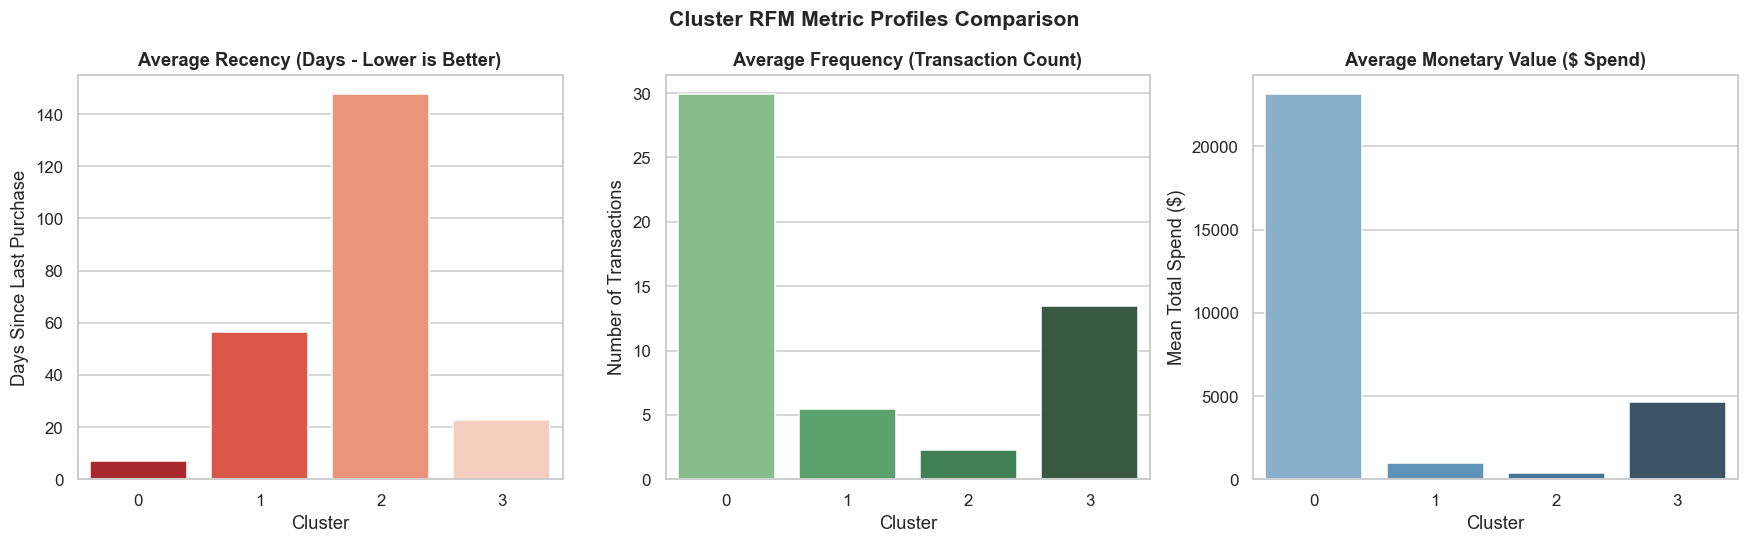

In [22]:
# 1x3 Visual Comparison of Mean RFM Metrics Across Clusters
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency Comparison
sns.barplot(data=cluster_profile, x='Cluster', y='Recency_Mean', ax=axes[0], palette='Reds_r')
axes[0].set_title('Average Recency (Days - Lower is Better)', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Days Since Last Purchase')

# Frequency Comparison
sns.barplot(data=cluster_profile, x='Cluster', y='Frequency_Mean', ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Frequency (Transaction Count)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Transactions')

# Monetary Comparison
sns.barplot(data=cluster_profile, x='Cluster', y='Monetary_Mean', ax=axes[2], palette='Blues_d')
axes[2].set_title('Average Monetary Value ($ Spend)', fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Mean Total Spend ($)')

plt.suptitle("Cluster RFM Metric Profiles Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
##  Section 6: Customer Personas & Strategic Business Recommendations

Based on the unscaled RFM profile analysis, we establish 4 distinct customer personas and formulate targeted business strategies for executive action:

---

###  Persona 1 — Cluster 0: VIP Champions
- **Customer Share**: **18.3%** ($55$ customers)
- **Revenue Contribution**: **67.7%** of total revenue (**$1,272,704.38**)
- **RFM Metrics**: Average Recency = **7.0 days** | Average Frequency = **29.9 transactions** | Average Spend = **$23,140.08**
- **Persona Description**: These are the company's most valuable elite customers. They purchase with extreme frequency, spent over $23K on average, and bought within the last week.
- **Strategic Action Plan**:
  - Implement a white-glove VIP loyalty program with a dedicated concierge service.
  - Provide exclusive early access to premium product launches and invite-only VIP events.
  - Reward them with surprise personalized appreciation gifts and zero-friction return privileges.

---

### Persona 2 — Cluster 3: Core Loyal Spenders
- **Customer Share**: **37.0%** ($111$ customers)
- **Revenue Contribution**: **27.3%** of total revenue (**$514,053.39**)
- **RFM Metrics**: Average Recency = **22.6 days** | Average Frequency = **13.4 transactions** | Average Spend = **$4,631.11**
- **Persona Description**: The backbone of steady revenue. They buy consistently once or twice a month, spend strongly (~$4.6K), and remain active.
- **Strategic Action Plan**:
  - Target with personalized product recommendations and cross-selling bundles.
  - Offer tier-upgrade incentives (e.g., "Spend $500 more this quarter to unlock VIP Champion perks").
  - Engage via loyalty points programs that incentivize increased purchase frequency.

---

###  Persona 3 — Cluster 1: At-Risk / Occasional Buyers
- **Customer Share**: **23.0%** ($69$ customers)
- **Revenue Contribution**: **3.6%** of total revenue (**$67,687.09**)
- **RFM Metrics**: Average Recency = **56.6 days** (~2 months inactive) | Average Frequency = **5.5 transactions** | Average Spend = **$980.97**
- **Persona Description**: Customers who previously bought occasionally but have gone silent for nearly 2 months. Their spending is modest (~$980), and they are at risk of churning completely.
- **Strategic Action Plan**:
  - Trigger automated "We Miss You!" email re-engagement campaigns featuring time-sensitive 15% discount vouchers.
  - Send customer satisfaction surveys to uncover potential pain points or friction during past purchases.
  - Re-engage through targeted social media ad retargeting showcasing trending products.

---

###  Persona 4 — Cluster 2: Dormant / Churned Customers
- **Customer Share**: **21.7%** ($65$ customers)
- **Revenue Contribution**: **1.3%** of total revenue (**$24,778.08**)
- **RFM Metrics**: Average Recency = **147.7 days** (~5 months inactive) | Average Frequency = **2.3 transactions** | Average Spend = **$381.20**
- **Persona Description**: Low-value customers who made only 1 or 2 purchases early in the year and haven't returned for nearly 5 months.
- **Strategic Action Plan**:
  - Minimize expensive direct marketing and ad spend to avoid wasting customer acquisition budget.
  - Include only in automated mass clearance sale emails or major holiday promotional blasts.
  - Remove from active retargeting channels if inactive beyond 180 days to protect sender reputation.


---
## Section 7: Key Project Takeaways & Business KPIs ("الـ K")

###  Summary KPI Matrix

| Metric | Overall Dataset | Cluster 0 (VIP) | Cluster 3 (Core) | Cluster 1 (At-Risk) | Cluster 2 (Dormant) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Customer Count** | **300** | 55 (18.3%) | 111 (37.0%) | 69 (23.0%) | 65 (21.7%) |
| **Total Spend ($)** | **$1,879,222.94** | $1,272,704.38 (67.7%) | $514,053.39 (27.3%) | $67,687.09 (3.6%) | $24,778.08 (1.3%) |
| **Mean Recency (Days)** | **46.8 days** | 7.0 days | 22.6 days | 56.6 days | 147.7 days |
| **Mean Frequency (Tx)** | **12.2 tx** | 29.9 tx | 13.4 tx | 5.5 tx | 2.3 tx |
| **Mean Monetary ($)** | **$6,264.08** | $23,140.08 | $4,631.11 | $980.97 | $381.20 |

### Key Conclusion
1. **Paretian Revenue Concentration**: 18.3% of customers (VIP Champions) drive over **67.7%** of total revenue. Customer retention strategies MUST prioritize protecting this VIP tier above all else.
2. **Actionable Segmentation ($k=4$)**: Combining RFM engineering, logarithmic skewness reduction, StandardScaler normalization, K-Means clustering, and PCA 2D visualization provides a mathematically robust and commercially actionable customer segmentation strategy.
3. **Implementation Ready**: The cluster labels assigned in `rfm['Cluster']` can be exported directly into marketing automation systems (HubSpot, Salesforce, Klaviyo) to power personalized campaign workflows.
